# CSCI 3202, Spring 2026
### Mancala Project

<br> 

### Your name: Lilian Ma

<br> 

---

# Mancala Game Implementation

In this assignment, you are tasked with implementing various functions for a Mancala game. The game is played on a board with specific rules, and you will need to implement the core game logic by completing the `play`, `valid_move`, and `winning_eval` functions. You are provided with the `init` and `display_board` functions. The assignment is divided into two parts:

## Mancala rules for this homework assignment
**(there are many different rules sets for Mancala.  Please read this before writing the code)**

* Players sit on opposite sides of the long edge of the board
* There are 6 small pits in the middle of the board and 2 large ones at each end.  The small ones in the middle and the large pit on your right are yours.  The small ones on the other side and the large pit to your opponent's right are theirs
* The large pits at the end of the board are called Mancalas
* Set up the board with 4 stones per small pit (none in the mancalas)
* On every turn, select a pit on your side of the board that contains one or more stones,  then distribute its stones, one stone per pit, in an counter-clockwise direction until you have no stones remaining
* If you encounter your opponent's mandala, skip it
* If you encounter your mancala, drop a stone into it
* If the last stone lands in an empty pit on your side of the board, capture this stone and any stones in your opponent's pit on the other side of the board, collect all of these stones, including the one that just landed, and place them into your mancala.
* If either player's pits are entirely empty, the game concludes. 
* The player who still has stones on his side of the board when the game concludes places all of these pieces into their mancala.
The player with the most stones in their mancala is declared the winner. If both players have an equal number of stones in their mancala, the game results in a tie.


## Part 1: Small Board (3 Pits of 2 Stones each) (60 points)

For the first part of the assignment, students will work on a small Mancala board. The board consists of 3 pits, each initially containing 2 stones. The students need to implement the following:

1. **play**: Implement the `play` function to allow players to take turns and make moves. The function should correctly distribute stones according to the specified game rules. The game should also switch between players after each play. **(20 points)**

2. **valid_move**: Implement the `valid_move` function to ensure that a player's chosen move is valid. It should check if the selected pit is not empty and falls within the allowed pit range. **(20 points)**

3. **winning_eval**: Implement the `winning_eval` function to determine when the game is over and which player wins. The game ends when any player's pits are all empty. The winner is the player with the most stones in their mancala. If both mancalas have the same number of stones, it's a tie. **(20 points)**

Students should test their code by playing a sequence of moves shown below.

P1 picks pit 1, P2 picks pit 2, P1 picks pit 3...and so on.  The pits are 1-indexed when displaying and picking to make a move.  Make sure that your code gives an invalid move error when the pit chosen is empty or the pit choice is out of range.




## Part 2: Play Against a Random Player (6 Pits of 4 Stones each) (40 points)

In the second part of the assignment, students will extend their implementation to a larger board. The board consists of 6 pits with 4 stones in each pit. In addition to the `play`, `valid_move`, and `winning_eval` functions, students need to create a random move generator for a random player. This random player selects a random valid pit with stones to make a move. The following steps are involved in creating the random move generator:

1. **Random Move Generator**: Define the `random_move_generator` that selects a random pit from the available non-empty pits for the random player. The random player should choose a move based on these criteria. \
Set the 'seed' value to ensure that the generated values remain consistent and reproducible when grading.

You may refer to these links: [How to generate random integers in Python](https://machinelearningmastery.com/how-to-generate-random-numbers-in-python/#:~:text=Random%20integer%20values%20can%20be,for%20the%20generated%20integer%20values.), [How to use seed in Python random](https://www.w3schools.com/python/ref_random_seed.asp)


The objective is to play up to **10** moves in total (5 moves by student, 5 moves by random player), allowing the students to verify whether their code correctly implements the Mancala game logic. **(20 points for correct implementation of Random Move Generator)**

The output submitted should reflect the state of the board and the moves played. **(10 points for playing game, 10 points for printing out results)**

**Please make sure to call the `display_board` function after each move for both the parts and run all the cells before submitting**

In [28]:
import random
random.seed(1099)
import copy

In [ ]:
class Mancala:
    def __init__(self, pits_per_player=6, stones_per_pit = 4):
        """
        The constructor for the Mancala class defines several instance variables:

        pits_per_player: This variable stores the number of pits each player has.
        stones_per_pit: It represents the number of stones each pit contains at the start of any game.
        board: This data structure is responsible for managing the Mancala board.
        current_player: This variable takes the value 1 or 2, as it's a two-player game, indicating which player's turn it is.
        moves: This is a list used to store the moves made by each player. It's structured in the format (current_player, chosen_pit).
        p1_pits_index: A list containing two elements representing the start and end indices of player 1's pits in the board data structure.
        p2_pits_index: Similar to p1_pits_index, it contains the start and end indices for player 2's pits on the board.
        p1_mancala_index and p2_mancala_index: These variables hold the indices of the Mancala pits on the board for players 1 and 2, respectively.
        """
        self.pits_per_player = pits_per_player
        self.board = [stones_per_pit] * ((pits_per_player+1) * 2)  # Initialize each pit with stones_per_pit number of stones 
        self.players = 2
        self.current_player = 1
        self.moves = []
        self.p1_pits_index = [0, self.pits_per_player-1]
        self.p1_mancala_index = self.pits_per_player
        self.p2_pits_index = [self.pits_per_player+1, len(self.board)-1-1]
        self.p2_mancala_index = len(self.board)-1
        
        # Zeroing the amount in Mancala for both players
        self.board[self.p1_mancala_index] = 0
        self.board[self.p2_mancala_index] = 0

    def display_board(self):
        """
        Displays the board in a user-friendly format
        """
        player_1_pits = self.board[self.p1_pits_index[0]: self.p1_pits_index[1]+1]
        player_1_mancala = self.board[self.p1_mancala_index]
        player_2_pits = self.board[self.p2_pits_index[0]: self.p2_pits_index[1]+1]
        player_2_mancala = self.board[self.p2_mancala_index]

        print('P1               P2')
        print('     ____{}____     '.format(player_2_mancala))
        for i in range(self.pits_per_player):
            if i == self.pits_per_player - 1:
                print('{} -> |_{}_|_{}_| <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            else:    
                print('{} -> | {} | {} | <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            
        print('         {}         '.format(player_1_mancala))
        turn = 'P1' if self.current_player == 1 else 'P2'
        print('Turn: ' + turn)

    def get_pit_index(self, pit):
        if self.current_player == 1:
            return self.p1_pits_index[0] + pit - 1  # Convert to 0-based index
        else:
            return self.p2_pits_index[0] + pit - 1  # Convert to 0-based index

    def is_current_players_pit(self, pit):
        """
        Function to check if the pit chosen by the current_player belongs to them (not a mancala pit).
        """
        if self.current_player == 1:
            return self.p1_pits_index[0] <= self.get_pit_index(pit) <= self.p1_pits_index[1]
        elif self.current_player == 2:
            return self.p2_pits_index[0] <= self.get_pit_index(pit) <= self.p2_pits_index[1]
        pass

    def valid_move(self, pit):
        """
        Function to check if the pit chosen by the current_player is a valid move.
        """
        if 1 <= pit <= self.pits_per_player and self.board[self.get_pit_index(pit)] > 0:
            return True
        
        return False
        # write your code here
        pass
        
    def random_move_generator(self):
        """
        Function to generate random valid moves with non-empty pits for the random player
        """
        if self.current_player == 1:
            valid_pits = [i for i in range(self.p1_pits_index[0], self.p1_pits_index[1]+1) if self.board[i] > 0]
        elif self.current_player == 2:
            valid_pits = [i for i in range(self.p2_pits_index[0], self.p2_pits_index[1]+1) if self.board[i] > 0]
        
        # generate a random move from the valid pits
        if valid_pits:
            index = random.choice(valid_pits)

            return index - (self.p1_pits_index[0] if self.current_player == 1 else self.p2_pits_index[0]) + 1  # Convert to 1-based index
        pass
    
    def play(self, pit):
        """
        This function simulates a single move made by a specific player using their selected pit. It primarily performs three tasks:
        1. It checks if the chosen pit is a valid move for the current player. If not, it prints "INVALID MOVE" and takes no action.
        2. It verifies if the game board has already reached a winning state. If so, it prints "GAME OVER" and takes no further action.
        3. After passing the above two checks, it proceeds to distribute the stones according to the specified Mancala rules.

        Finally, the function then switches the current player, allowing the other player to take their turn.
        """
        # print(f"Player {self.current_player} chose pit {pit}")
        
        if self.winning_eval():
            print("GAME OVER")
            return
        
        if not self.valid_move(pit):
            print("INVALID MOVE")
            return
        
        # Append the move to the moves list
        self.moves.append((self.current_player, pit))
        
        # Empty stones in the chosen pit and distribute them according to the rules
        current_index = self.get_pit_index(pit)
        stones = self.board[current_index]
        self.board[current_index] = 0# Start from the chosen pit index

        for i in range(stones):
            # Skip the opponent's Mancala
            current_index = (current_index + 1) % len(self.board)
            if (current_index == self.p2_mancala_index and self.current_player == 1) or (current_index == self.p1_mancala_index and self.current_player == 2):
                current_index = (current_index + 1) % len(self.board)
            
            # Check for capture condition
            if i == stones - 1 and self.is_current_players_pit(current_index) and self.board[current_index] == 0:
                # Capture the opponent's and current stones
                if self.current_player == 1:
                    opposite_index = self.p2_pits_index[1] - (current_index - self.p1_pits_index[0])
                    self.board[self.p1_mancala_index] += self.board[opposite_index] + 1
                elif self.current_player == 2:
                    opposite_index = self.p1_pits_index[1] - (current_index - self.p2_pits_index[0])
                    self.board[self.p2_mancala_index] += self.board[opposite_index] + 1
                
                self.board[opposite_index] = 0
                self.board[current_index] = 0
                return
                
            # If not capture condition, simply place a stone in the current pit
            self.board[current_index] += 1

        self.current_player = 2 if self.current_player == 1 else 1
        
        return self.board
    
    def winning_eval(self):
        p1_empty = all(self.board[i] == 0 for i in range(self.p1_pits_index[0], self.p1_pits_index[1]+1))
        p2_empty = all(self.board[i] == 0 for i in range(self.p2_pits_index[0], self.p2_pits_index[1]+1))
        return p1_empty or p2_empty

# ---------- DECISION TREE ----------
    def clone(self):
        """Deep copy of the game state for simulations"""
        return copy.deepcopy(self)

    def evaluate(self):
        """Simple evaluation: difference in Mancala stones"""
        return self.board[self.p1_mancala_index] - self.board[self.p2_mancala_index]

    def minimax(self, depth, alpha, beta, maximizing):
        """
        Minimax algorithm with alpha-beta pruning
        """
        if depth == 0 or self.winning_eval():
            return self.evaluate(), None

        moves = [i+1 for i in range(self.pits_per_player) if self.valid_move(i+1)]

        if maximizing:
            max_eval = float('-inf')
            best_move = None
            for move in moves:
                game_copy = self.clone()
                game_copy.play(move)
                extra_turn = game_copy.current_player == self.current_player
                score, _ = game_copy.minimax(depth-1, alpha, beta, maximizing if extra_turn else False)
                if score > max_eval:
                    max_eval = score
                    best_move = move
                alpha = max(alpha, score)
                if beta <= alpha:
                    break
            return max_eval, best_move
        else:
            min_eval = float('inf')
            best_move = None
            for move in moves:
                game_copy = self.clone()
                game_copy.play(move)
                extra_turn = game_copy.current_player == self.current_player
                score, _ = game_copy.minimax(depth-1, alpha, beta, not maximizing if not extra_turn else maximizing)
                if score < min_eval:
                    min_eval = score
                    best_move = move
                beta = min(beta, score)
                if beta <= alpha:
                    break
            return min_eval, best_move

    def make_best_move(self, depth=4):
        """
        Function to make the best move using decision tree (minimax + alpha-beta pruning)
        """
        maximizing = True if self.current_player == 1 else False
        _, best_move = self.minimax(depth, float('-inf'), float('inf'), maximizing)
        return best_move


In [16]:
# Mancala part 1 
game = Mancala(3,2)
game.display_board()

# Player 1 selects pit 1 (1-based index)
game.play(1)
game.display_board()

# Player 2 selects pit 2
game.play(2)
game.display_board()

# Player 1 selects pit 3
game.play(3)
game.display_board()

# Player 2 selects pit 2
game.play(2)
game.display_board()

# Player 1 selects pit 1
game.play(1)
game.display_board()

# Printing the list of moves
print("\nList of valid moves:")
for move in game.moves:
    player, pit = move
    print(f"Player {player} selected pit {pit}")


P1               P2
     ____0____     
1 -> | 2 | 2 | <- 3
2 -> | 2 | 2 | <- 2
3 -> |_2_|_2_| <- 1
         0         
Turn: P1
P1               P2
     ____0____     
1 -> | 0 | 2 | <- 3
2 -> | 3 | 2 | <- 2
3 -> |_3_|_2_| <- 1
         0         
Turn: P2
P1               P2
     ____1____     
1 -> | 0 | 3 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_3_|_2_| <- 1
         0         
Turn: P1
P1               P2
     ____1____     
1 -> | 0 | 3 | <- 3
2 -> | 3 | 1 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P2
P1               P2
     ____1____     
1 -> | 0 | 4 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P1
INVALID MOVE
P1               P2
     ____1____     
1 -> | 0 | 4 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P1

List of valid moves:
Player 1 selected pit 1
Player 2 selected pit 2
Player 1 selected pit 3
Player 2 selected pit 2


#### Expected output for part 1

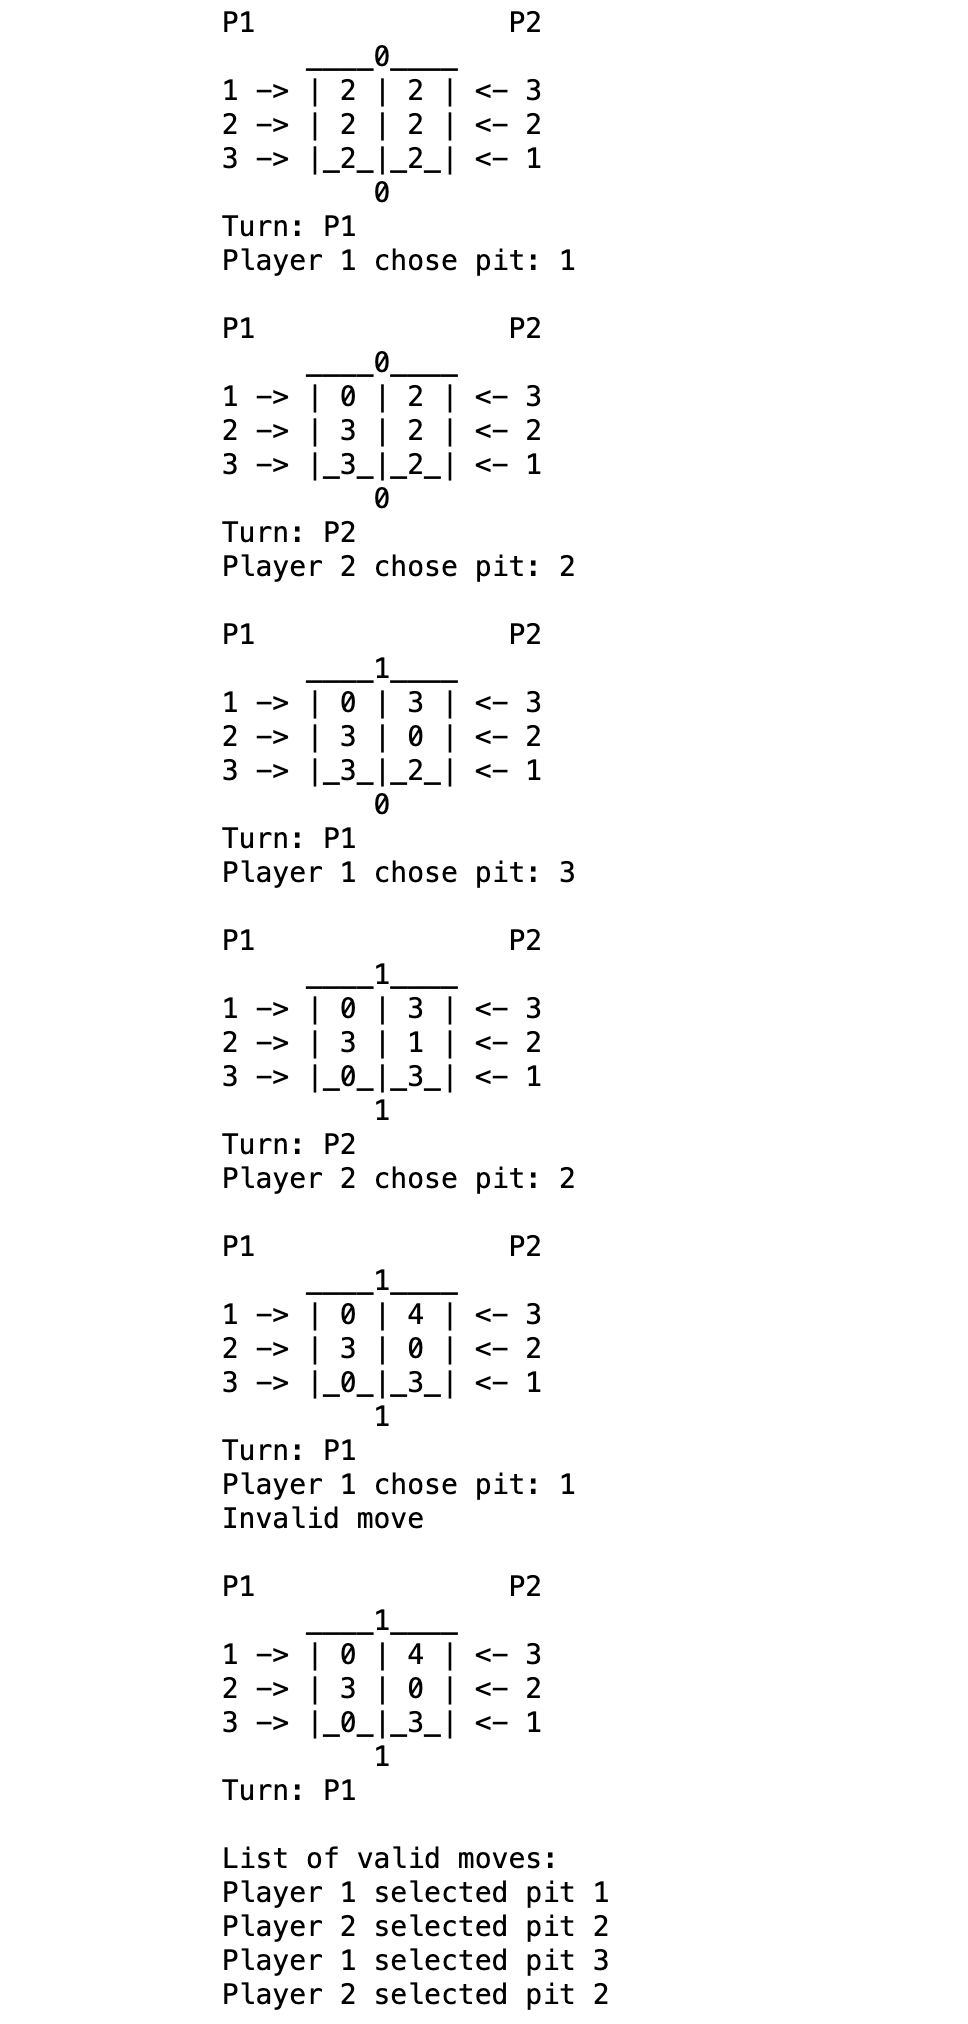

In [8]:
# Mancala part 2
game = Mancala()
game.display_board()

for _ in range(10):
    game.play(game.random_move_generator())
    game.display_board()

# Printing the list of moves
print("\nList of valid moves:")
for move in game.moves:
    player, pit = move
    print(f"Player {player} selected pit {pit}")


P1               P2
     ____0____     
1 -> | 4 | 4 | <- 6
2 -> | 4 | 4 | <- 5
3 -> | 4 | 4 | <- 4
4 -> | 4 | 4 | <- 3
5 -> | 4 | 4 | <- 2
6 -> |_4_|_4_| <- 1
         0         
Turn: P1
Player 1 chose pit 3
P1               P2
     ____0____     
1 -> | 4 | 4 | <- 6
2 -> | 4 | 4 | <- 5
3 -> | 0 | 4 | <- 4
4 -> | 5 | 4 | <- 3
5 -> | 5 | 4 | <- 2
6 -> |_5_|_4_| <- 1
         0         
Turn: P1
Player 1 chose pit 2
P1               P2
     ____0____     
1 -> | 4 | 4 | <- 6
2 -> | 0 | 4 | <- 5
3 -> | 1 | 4 | <- 4
4 -> | 6 | 4 | <- 3
5 -> | 6 | 4 | <- 2
6 -> |_6_|_4_| <- 1
         0         
Turn: P2
Player 2 chose pit 4
P1               P2
     ____1____     
1 -> | 5 | 5 | <- 6
2 -> | 0 | 5 | <- 5
3 -> | 1 | 0 | <- 4
4 -> | 6 | 4 | <- 3
5 -> | 6 | 4 | <- 2
6 -> |_6_|_4_| <- 1
         0         
Turn: P1
Player 1 chose pit 5
P1               P2
     ____1____     
1 -> | 5 | 5 | <- 6
2 -> | 0 | 5 | <- 5
3 -> | 1 | 1 | <- 4
4 -> | 6 | 5 | <- 3
5 -> | 0 | 5 | <- 2
6 -> |_7_|_5_| <- 1


In [49]:

tie_sum = 0
player1_sum = 0
player2_sum = 0
total = 100


# Simulate 100 Mancala games, player b is ai
for i in range(1, 101):
    game = Mancala()
    
    # Play until the game ends
    while not game.winning_eval():
        if game.current_player == 2:
            # AI move
            move = game.make_best_move(depth=4)
        else:
            # Random move
            move = game.random_move_generator()
        
        game.play(move)
    
    # Determine winner
    p1_score = game.board[game.p1_mancala_index]
    p2_score = game.board[game.p2_mancala_index]
    
    if p1_score > p2_score:
        player1_sum += 1
    elif p2_score > p1_score:
        player2_sum += 1
    else:
        tie_sum += 1
    
    print(f"Progress: {i}/{total}", end='\r')

print(f"Player 1 (Random) wins: {player1_sum}")
print(f"Player 2 (AI) wins: {player2_sum}")
print(f"Ties: {tie_sum}")

Player 1 (Random) wins: 11
Player 2 (AI) wins: 86
Ties: 3


In [51]:
# Play random vs random for 100 games

tie_sum = 0
player1_sum = 0
player2_sum = 0
total = 100

player1_turns = 0
player2_turns = 0

for i in range(1,total+1):
    game = Mancala()
    
    # Play until the game ends
    while not game.winning_eval():
        move = game.random_move_generator()
        game.play(move)
        if game.current_player == 1:
            player1_turns += 1
        else:
            player2_turns += 1
    
    # Determine winner
    p1_score = game.board[game.p1_mancala_index]
    p2_score = game.board[game.p2_mancala_index]
    
    if p1_score > p2_score:
        player1_sum += 1
    elif p2_score > p1_score:
        player2_sum += 1
    else:
        tie_sum += 1
    
    print(f"Progress: {i}/{total}", end='\r')

print(f"Player 1 (Random) wins: {player1_sum}, turns/game average: {player1_turns/100}")
print(f"Player 2 (Random) wins: {player2_sum}, turns/game average: {player2_turns/100}")
print(f"Ties: {tie_sum}")



Player 1 (Random) wins: 83, turns/game average: 22.87
Player 2 (Random) wins: 13, turns/game average: 19.5
Ties: 4


# Statistics:
## Random vs Random
Player 1 always won by a lot, I'm not sure why, maybe my random is implemented wrong or the first player always has advantage if random.

Player 1 (Random) wins: 83, turns/game average: 22.87

Player 2 (Random) wins: 13, turns/game average: 19.5

Ties: 4

Player one has about 3 more turns than player 2, thus will have an advantage.


## Random Player 1 vs AI player 2

Player 1 (Random) wins: 11

Player 2 (AI) wins: 86

Ties: 3
